 #  **Assignment 01**

 

---

##  **Submitted To**
### **Instructor Name:** _[`Dr. Zafar Khatak`]_

---

##  **Submitted By**
### **Name:** _[`Muhammad Ali Saagar`]_  
### **Roll Number:** _[`23021519-095`]_  
### **Section:** _[`C`]_

---

<br>

 

In [ ]:
# Importing the necessary libraries and all other models that are necessary at once 
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split 


## Creating the DataSet 

In [50]:
# Using a fixed sample so that it can not be changed
np.random.seed(42)
# Generating data for 400 students
n=400
# Study hours between 1 to 10, Sleep hours between 3 to 10, Coffee intake between 0 to 5, Screen time between 1 to 8, Attendance between 50 to 100
study_hours = np.random.uniform(1, 10 , n )
sleep_hours = np.random.uniform(3 , 10 , n)
coffee = np.random.uniform(0 ,5 , n) 
screen_time =np.random.uniform(1, 8 , n)
attendance = np.random.uniform(50 , 100 , n)

# Calculating GPA based on the formula , The formula is designed to reflect the positive impact of study hours, sleep hours, and 
# attendance on GPA, while accounting for the negative effects of screen time and coffee intake. 


gpa = (
    0.4 * study_hours +
    0.2 * sleep_hours -
    0.2 * screen_time -
    0.1 * coffee +
    0.3 * (attendance/20)
)
# The GPA is then clipped to ensure it falls within the range of 0 to 4, which is a common scale for GPA.
gpa = np.clip(gpa , 0,4)
# And a pass/fail label is created based on whether the GPA is above or below 2.0.
pass_fail = (gpa >=2 ).astype(int)

# Creating a DataFrame to hold the data
data = pd.DataFrame({
    "StudyHours": study_hours , 
    "SleepHours" : sleep_hours , 
    "ScreenTime": screen_time , 
    "CoffeeIntake":coffee , 
    "Attendance" : attendance ,
    "GPA" : gpa ,
    "Pass" : pass_fail

})
# data.head()
# data.head(20)
data.head(34)


,StudyHours,SleepHours,ScreenTime,CoffeeIntake,Attendance,GPA,Pass
0,4.370861,3.721867,6.307842,3.536193,59.593366,1.771431,0
1,9.556429,9.317870,1.172108,0.762695,66.168578,4.000000,1
2,7.587945,6.536767,1.154865,2.881442,61.332820,4.000000,1
3,6.387926,8.785202,3.265272,3.033575,67.749815,4.000000,1
4,2.404168,5.240347,4.420502,2.120653,53.471192,1.715639,0
5,2.403951,9.268663,6.392852,3.682221,75.952990,2.307815,1
6,1.522753,5.724412,5.783068,4.671835,53.380628,0.930896,0
7,8.795585,3.075864,4.121319,4.627843,90.017825,4.000000,1
8,6.410035,9.337674,2.915387,2.254197,61.685604,4.000000,1
9,7.372653,3.639007,7.979872,0.566190,77.000596,3.179278,1


In [51]:
data.describe()

,StudyHours,SleepHours,ScreenTime,CoffeeIntake,Attendance,GPA,Pass
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,5.447716,6.498054,4.476785,2.517773,74.951695,3.161692,0.870000
std,2.643807,2.056594,2.024925,1.484165,14.434499,0.881242,0.336725
min,1.045554,3.075864,1.034580,0.023160,50.160913,0.822230,0.000000
25%,3.171517,4.692906,2.661626,1.163188,62.053714,2.511025,1.000000
50%,5.605460,6.521482,4.478796,2.594389,75.444567,3.378599,1.000000
75%,7.727700,8.323840,6.071980,3.822507,87.614590,4.000000,1.000000
max,9.914546,9.998024,7.995896,4.989671,99.917376,4.000000,1.000000


## Separation of  input features (X) and targets (Y)
`X`  : Training features 

`Y_class` : for classification (Pass/Fail)

`Y_reg` : for regression (GPA prediction )

In [52]:
# Preparing the feature matrix (X) and target vectors (Y) for both classification and regression tasks.
X = data[["StudyHours", "SleepHours", "ScreenTime", "CoffeeIntake", "Attendance"]] 
Y_class = data["Pass"]
Y_reg = data["GPA"]

## Data Visualization

 Here we will  visualize relationships between:

- Study Hours vs GPA
- Sleep Hours vs GPA
- Study Hours vs Pass/Fail

I am making scatterplot using matplot.lib

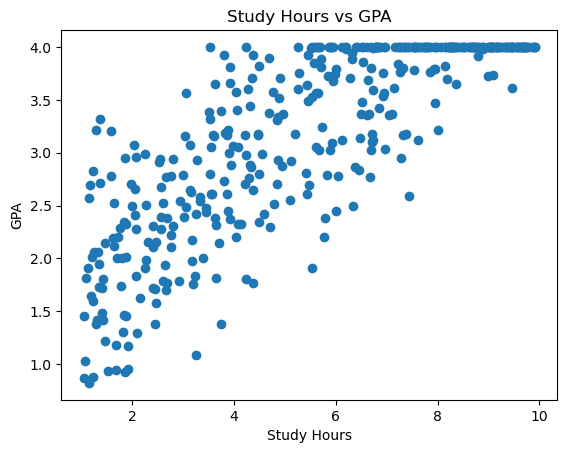

In [53]:
# Creating the plot using plt 
plt.scatter(data["StudyHours"], data["GPA"])
# Defining X label
plt.xlabel("Study Hours")
# Defining Y label
plt.ylabel("GPA")
# Defining title
plt.title("Study Hours vs GPA")
# Showing the plot
plt.show()

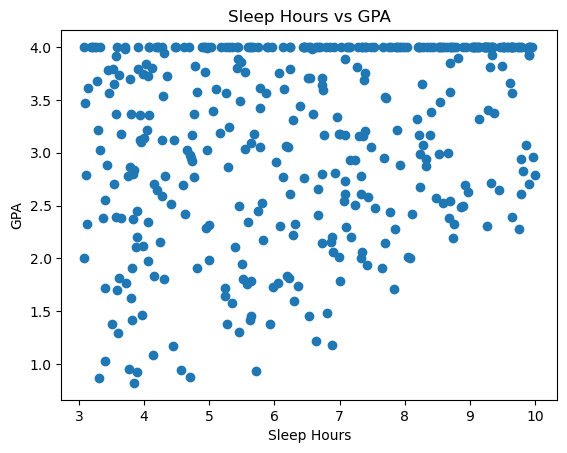

In [54]:
plt.scatter(data["SleepHours"], data["GPA"])
plt.xlabel("Sleep Hours")
plt.ylabel("GPA")
plt.title("Sleep Hours vs GPA")
plt.show()

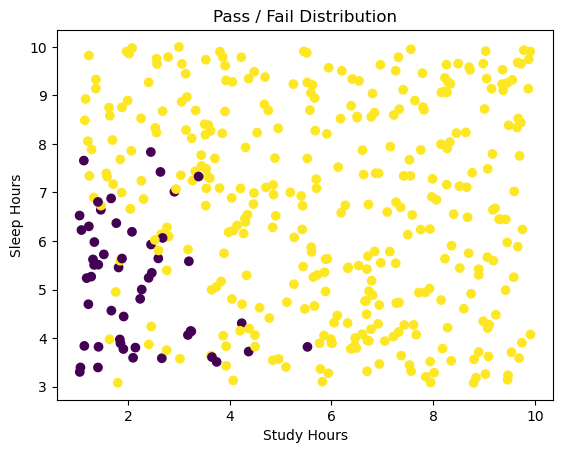

In [55]:
# Scatter plot for Pass/Fail distribution based on Study Hours and Sleep Hours
plt.scatter(data["StudyHours"], data["SleepHours"], c=data["Pass"])
plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.title("Pass / Fail Distribution")
plt.show()

# Q1 -- Splitting Dataset into Training and Testing Sets


- 80% Training
- 20% Testing
 

## Splitting Dataset for Classification (Pass Prediction)

In [56]:
# Splitting dataset into training and testing sets
# c is written for classification 
# test_size is 0.2 which means 20% of the data will be used for testing and 80% for training
# random state mean same split every time 
Train_X_c , Test_X_c , Train_Y_c , Test_Y_c = train_test_split(X , Y_class , test_size=0.2 , random_state=42)

##  Viewing Train and Test Samples for classification

In [57]:
# showing the first 5 rows of the training and testing sets for classification
print("Train_X  (Classification)")
print(Train_X_c.head())

print("\nTrain_Y (Classification)")
print(Train_Y_c.head())

print("\n Test_X (Classification)")
print(Test_X_c.head())

print("\n Test_Y Classification")
print(Test_Y_c.head())

Train_X  (Classification)
     StudyHours  SleepHours  ScreenTime  CoffeeIntake  Attendance
3      6.387926    8.785202    3.265272      3.033575   67.749815
18     4.887505    7.707629    5.581578      0.273808   77.889171
202    2.454658    4.239073    1.256700      4.364729   67.662570
250    3.650040    3.608442    4.480223      4.373508   64.295339
274    5.602082    5.872778    3.289232      4.938612   86.640077

Train_Y (Classification)
3      1
18     1
202    1
250    0
274    1
Name: Pass, dtype: int64

 Test_X (Classification)
     StudyHours  SleepHours  ScreenTime  CoffeeIntake  Attendance
209    2.447272    7.832764    7.077899      2.447125   54.919782
280    9.010048    8.719504    6.724840      3.931725   84.444265
33     9.539970    3.707859    1.217939      0.881935   89.772498
210    5.938604    3.275185    2.440888      1.106047   83.015136
93     6.051495    4.316848    5.826255      1.985918   57.318700

 Test_Y Classification
209    0
280    1
33     1
210    1


## Splitting Dataset for Regression (GPA prediction)

In [58]:
# r with all variables is written for regression
Train_X_r , Test_X_r , Train_Y_r , Test_Y_r = train_test_split(
    X , Y_reg , random_state=42 , train_size=0.2)


## Viewing Training and Test samples for regression (GPA prediction)

In [59]:
# showing the first 5 rows of the training and testing sets for regression
print("Train_X (Regression)")
print(Train_X_r.head())

print("\nTrain_Y (Regression)")
print(Train_Y_r.head())


print("\nTest_X (Regression)")
print(Test_X_r.head())

print("\nTest_Y (Regression)")
print(Test_Y_r.head())


Train_X (Regression)
     StudyHours  SleepHours  ScreenTime  CoffeeIntake  Attendance
212    6.867651    7.395303    2.888247      4.720297   63.252321
295    5.700189    7.274340    5.677490      0.882640   86.653565
364    9.473183    3.234727    6.758300      0.803799   78.593614
251    4.465880    6.759746    5.324931      2.644686   90.797347
390    9.914546    4.073460    5.847053      0.336753   88.275645

Train_Y (Regression)
212    4.000000
295    3.810985
364    4.000000
251    3.170806
390    4.000000
Name: GPA, dtype: float64

Test_X (Regression)
     StudyHours  SleepHours  ScreenTime  CoffeeIntake  Attendance
209    2.447272    7.832764    7.077899      2.447125   54.919782
280    9.010048    8.719504    6.724840      3.931725   84.444265
33     9.539970    3.707859    1.217939      0.881935   89.772498
210    5.938604    3.275185    2.440888      1.106047   83.015136
93     6.051495    4.316848    5.826255      1.985918   57.318700

Test_Y (Regression)
209    1.708966
2

In [60]:
# Checking the sizes of the training and testing sets for both classification and regression
print("Classification Train Size:", len(Train_X_c))
print("Classification Test Size:", len(Test_X_c))

print("Regression Train Size:", len(Train_X_r))
print("Regression Test Size:", len(Test_X_r))

Classification Train Size: 320
Classification Test Size: 80
Regression Train Size: 80
Regression Test Size: 320


---

# Q2 -- KNN Algorithm (Class-Based Implementation)

Implementing KNN using OOP.


In [61]:
# (KNN) Class
class KNN:
    # Constructor , self means the object itself , it is used to access the attributes and methods of the class ,
    #  k is the number of nearest neighbors 
    def __init__(self , k=3):
        self.k = k 
     # fit method store the training data in the object for later use during prediction
    def fit( self , X , Y ):
        self.X_train = X.values       # convert input features to numpy array
        self.Y_train = Y.values 
    # function to calculate the eucledian distance between two points
    def eucledian_dist(self , X1 , X2 ) :
        # formula for eucledian distance
        return np.sqrt(np.sum((X1-X2)**2))
    # to make predictions for test data
    def predict(self , X ):
        # list to store the predictions for each test point
        predictions=[]

        # make predictions for test data
        for test_point in X.values : 
            distances = []

            # finding distances between the test point and all training points and storing them in a list
            for train_point in self.X_train: 
                dist =  self.eucledian_dist(test_point , train_point)
                distances.append(dist)
            # Getting the k closest points by sorting the distances 
            k_indices = np.argsort(distances)[:self.k]
            # Getting the labels of the k closest points
            k_lables = self.Y_train[k_indices]
        
            # Making the prediction by taking the most common label among the k closest points 
            # set remove the duplicates , key tells to choose the label with highest frequency
            prediction = max(set(k_lables) , key=list(k_lables).count)

            predictions.append(prediction)
        return np.array(predictions)
    



In [62]:
# creeating the model with 3 neighbors
knn_model = KNN(k=3)
# fitting the model (storing training data in the model)
knn_model.fit(Train_X_c , Train_Y_c)
# making predictions
prediction_class = knn_model.predict(Test_X_c)

print(prediction_class[:10])

[1 1 1 1 1 1 0 1 1 1]


## Feature Space Visualization (Class-Based KNN)


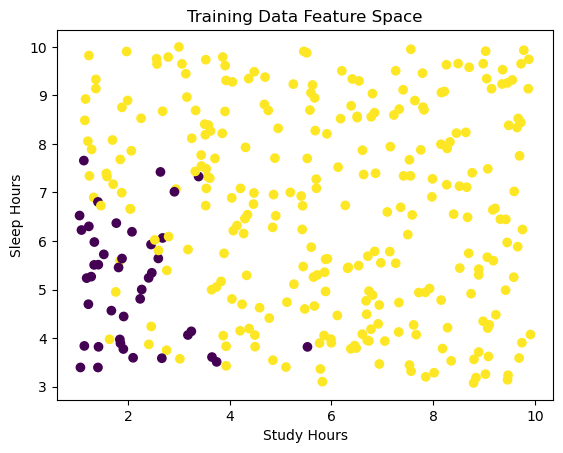

In [63]:
plt.scatter(Train_X_c["StudyHours"], Train_X_c["SleepHours"], c=Train_Y_c)
                                                            # coloring on the basis of pass or fail
plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.title("Training Data Feature Space")
plt.show()

---

 # Q3 -- KNN Algorithm (Procedural Implementation)

In [64]:
# calculating the eucledian distance between two points
def eucledian_dist(x1 , x2) :
    return np.sqrt(np.sum((x1-x2)**2))

In [65]:
# functions to make predictons 
def knn_predict(X_trian , Y_train , X_test, k=3):
    # list to store the predictions for each test point
    predictions = []
    # convert the input data to numpy arrays for easier manipulation
    X_trian = X_trian.values  
    Y_train = Y_train.values
    # making predictions for test data
    for test_point in X_test.values : 
        # list to store the distances between the test point and all training points
        distances = []
        # finding distances between the test point and all training points and storing them in a list
        for train_point in X_trian : 
            dist = eucledian_dist(test_point , train_point)
            distances.append(dist)
            # Getting the k closest points by sorting the distances
        k_indices = np.argsort(distances)[:k]
        k_lables = Y_train[k_indices]
        # Making the prediction by taking the most common label among the k closest points
        predicion = max(set(k_lables) , key=list(k_lables).count)
        predictions.append(predicion)

    return np.array(predictions)

In [66]:
# creating the model with 3 neighbors and making predictions
modl = knn_predict(Train_X_c , Train_Y_c , Test_X_c , k=3)
# modl
modl[:10]

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1])

## Feature Space Visualization (Procedural KNN)

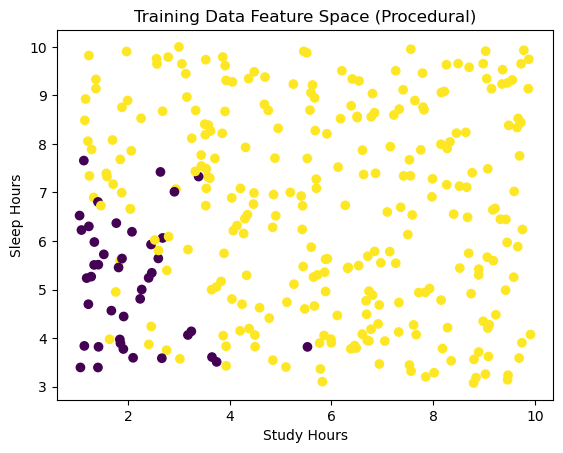

In [67]:
plt.scatter(Train_X_c["StudyHours"], Train_X_c["SleepHours"], c=Train_Y_c)
plt.xlabel("Study Hours")
plt.ylabel("Sleep Hours")
plt.title("Training Data Feature Space (Procedural)")
plt.show()

--- 

# Q4 -- Scholarship Eligibility Prediction

Predict whether a student is eligible for scholarship based on:

- Study Hours
- Sleep Hours
- Attendance

Eligible = 1 if GPA > 3

In [68]:
data.head()

,StudyHours,SleepHours,ScreenTime,CoffeeIntake,Attendance,GPA,Pass
0,4.370861,3.721867,6.307842,3.536193,59.593366,1.771431,0
1,9.556429,9.317870,1.172108,0.762695,66.168578,4.000000,1
2,7.587945,6.536767,1.154865,2.881442,61.332820,4.000000,1
3,6.387926,8.785202,3.265272,3.033575,67.749815,4.000000,1
4,2.404168,5.240347,4.420502,2.120653,53.471192,1.715639,0


In [69]:
# Scholarship is the label we want to predict , it is 1 if GPA is greater than 3 and 0 otherwise
# astype(int) is used to convert the values to integers (1 and 0)
scholarship = (data["GPA"] >3).astype(int)

# Training data for question 4
X_q4 = data[["StudyHours" , "SleepHours" , "Attendance"] ]
# prediction for question 4
Y_q4 = scholarship 

Train_X_q4 , Test_X_q4 , Train_Y_q4 , Test_Y_q4 = train_test_split( X_q4 , Y_q4 , train_size=0.2 , random_state=32)

# creating the model with 3 neighbors and making predictions for question 4
predict_q4 = knn_predict( Train_X_q4 , Train_Y_q4 , Test_X_q4 , k=3)
predict_q4[:12]

array([0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0])

 ---

# Q5 -- Healthy Lifestyle Prediction

Healthy if:
Sleep > 6 AND Screen Time < 4

I am using only 3 features `SleepHours, ScreenTime, CoffeeIntake `for this.

In [70]:
# similarly healthy is the label we want to predict  
healthy = ((data["SleepHours"] > 6) & (data["ScreenTime"] < 4)).astype(int)

# Training and prediction for question 5
X_q5 = data[["SleepHours", "ScreenTime", "CoffeeIntake"]]
Y_q5 = healthy

Train_X_q5, Test_X_q5, Train_Y_q5, Test_Y_q5 = train_test_split(
    X_q5, Y_q5, test_size=0.2, random_state=42
)
# creating the model with 3 neighbors and making predictions for question 5
pred_q5 = knn_predict(Train_X_q5, Train_Y_q5, Test_X_q5, k=3)
pred_q5[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

---

# Q6 -- Productivity Prediction

Productive if:

Study Hours > 5 AND Screen Time < 5 . 

I am using 2 features for predicting productivity i.e  ` Study Hours and Screen Time ` 

In [71]:
# productive is the lable we want to predict
productive = ((data["StudyHours"] > 5) & (data["ScreenTime"] < 5)).astype(int)

# Training and prediction for question 6
X_q6 = data[["StudyHours", "ScreenTime"]]
Y_q6 = productive

# Splitting the data
Train_X_q6, Test_X_q6, Train_Y_q6, Test_Y_q6 = train_test_split(
    X_q6, Y_q6, test_size=0.2, random_state=42
)

# making a model for question 6
pred_q6 = knn_predict(Train_X_q6, Train_Y_q6, Test_X_q6, k=3)
pred_q6[:10]

array([0, 0, 1, 1, 0, 0, 0, 0, 0, 1])

---

# Q7 -- High Attendance Prediction

High attendance if Attendance > 80%

In [72]:
# High attendance is the label to predict here 
high_attendance = (data["Attendance"] > 80).astype(int)

# Training and prediction for question 7
X_q7 = data[["StudyHours", "CoffeeIntake"]]
Y_q7 = high_attendance

# Splitting the data
Train_X_q7, Test_X_q7, Train_Y_q7, Test_Y_q7 = train_test_split(
    X_q7, Y_q7, test_size=0.2, random_state=42
)

# Creating the model and making predictions 
pred_q7 = knn_predict(Train_X_q7, Train_Y_q7, Test_X_q7, k=3)
pred_q7[:10]

array([1, 0, 0, 0, 1, 0, 1, 0, 0, 1])

---

# Q8 -- Risk of Failure Prediction

At risk if:

Study Hours < 3 AND Sleep < 5

In [73]:
# creating the risk label to predict , it is 1 if study hours are less than 3 and sleep hours are less than 5 , otherwise it is 0
risk = ((data["StudyHours"] < 3) & (data["SleepHours"] < 5)).astype(int)

# Training and prediction 
X_q8 = data[["StudyHours", "SleepHours"]]
Y_q8 = risk

#Splitting the data
Train_X_q8, Test_X_q8, Train_Y_q8, Test_Y_q8 = train_test_split(
    X_q8, Y_q8, test_size=0.2, random_state=42
)

# Creating the model and making predictions 
pred_q8 = knn_predict(Train_X_q8, Train_Y_q8, Test_X_q8, k=3)
pred_q8[:10]


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

---

# Q9 --- Balanced Lifestyle Prediction

Balanced if:

Study between 4–7 AND Sleep between 6–8

In [74]:
# predicting label balanced which is 1 if study hours are between 4 and 7 and sleep hours are between 6 and 8 , otherwise it is 0
balanced = (
    (data["StudyHours"] >= 4) & (data["StudyHours"] <= 7) &
    (data["SleepHours"] >= 6) & (data["SleepHours"] <= 8)
).astype(int)

# Training and prediction for question 9
X_q9 = data[["StudyHours", "SleepHours"]]
Y_q9 = balanced

# Splitting the data
Train_X_q9, Test_X_q9, Train_Y_q9, Test_Y_q9 = train_test_split(
    X_q9, Y_q9, test_size=0.2, random_state=42
)

# Creating the model and making predictions
pred_q9 = knn_predict(Train_X_q9, Train_Y_q9, Test_X_q9, k=3)
pred_q9

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

# Q10 --  Calculating Distance   (Classification)

calculating distance between a test sample and training samples using:

- Euclidean Distance
- Manhattan Distance
- Minkowski / Chebyshev Distance

In [75]:
# function to calculate the eucledian distance  
def euclidean(x1 , x2):
    return np.sqrt(np.sum((x1-x2)**2))

# function to calculate the manhattan distance  
def manhattan(x1 , x2):
    return np.sum(np.abs((x1-x2)))
  
# Chebyshev distance = max absolute difference among features
# It represents the case of Minkowski distance when a is infinity
# As a increases, larger differences dominate the calculation and smaller ones become negligible
# In the limit (p = infinity), only the largest difference matters, so we take max(|x1 - x2|)
def chebyshev(x1 , x2):
    return np.max(np.abs(x1-x2))

select one test sample


In [76]:
 # Select the first row from the test dataset and convert it into a NumPy array (single test sample)
test_sample = Test_X_c.iloc[0].values

# Convert the entire training feature set into a NumPy array (all training samples)
train_samples = Train_X_c.values


making arrays for distances from each sample 

In [77]:
# Initialize empty lists to store different distance metrics for each training sample
euclid_distances = []   # stores Euclidean distances
manhat_distances = []   # stores Manhattan distances
cheby_distances = []    # stores Chebyshev distances

# Loop through each training sample
for sample in train_samples:
    
    # Compute Euclidean distance between test sample and current training sample
    euclid_distances.append(euclidean(test_sample, sample))
    
    # Compute Manhattan distance  
    manhat_distances.append(manhattan(test_sample, sample))
    
    # Compute Chebyshev distance  
    cheby_distances.append(chebyshev(test_sample, sample))

# Display first 6 computed Euclidean distances
print("Euclidean:", euclid_distances[:6])

# Display Manhattan distances
print("Manhattan:", manhat_distances[:6])

# Display Chebyshev distances
print("Chebyshev:", cheby_distances[:6])


Euclidean: [np.float64(13.9973456751729), np.float64(23.249203794637104), np.float64(14.589615271874246), np.float64(10.846726931795647), np.float64(32.257293275747074), np.float64(20.229463117021584)]
Manhattan: [np.float64(22.122203006536072), np.float64(29.20439278344964), np.float64(24.08266765022006), np.float64(19.326705486689633), np.float64(43.11524385422614), np.float64(25.575750585376667)]
Chebyshev: [np.float64(12.830032805926997), np.float64(22.96938838283139), np.float64(12.742787939433349), np.float64(9.375556976288145), np.float64(31.720294752642666), np.float64(19.928391659621646)]


---

# Q--11 Distance Metrics (Regression)

Selecting Regression Sample

In [78]:
test_sample_r = Test_X_r.iloc[0].values
train_sample_r = Train_X_r.values

Computing distances 

In [79]:
euclid_dist_r = []
manhat_dist_r =[]
cheby_dist_r = []

for sample in train_sample_r:
    euclid_dist_r.append(euclidean(test_sample_r, sample))
    manhat_dist_r.append(manhattan(test_sample_r, sample)) 
    cheby_dist_r.append(chebyshev(test_sample_r , sample))

print("Euclidean:" , euclid_dist_r[:6])
print("Manhattan:" , manhat_dist_r[:6])
print("Chebyshev:" , cheby_dist_r[:6])


Euclidean: [np.float64(10.57746747673219), np.float64(31.97397384983055), np.float64(25.174556682018938), np.float64(35.99357862335355), np.float64(34.474262228006054), np.float64(24.817752995184502)]
Manhattan: [np.float64(19.653202440506703), np.float64(38.51001672875962), np.float64(37.26070272114702), np.float64(40.919718699201226), np.float64(47.92365797292126), np.float64(32.09431433162695)]
Chebyshev: [np.float64(8.332538930580334), np.float64(31.733782315813876), np.float64(23.673831075689456), np.float64(35.87756446276099), np.float64(33.35586246388562), np.float64(24.468685557440047)]


---

# Q --12 Effect of different values of k  

In [80]:
 # list of selected K values
k_values = [1, 5, 20, 50, 100 ,n]

accuracies = []

# loop for each k
for k in k_values:
    
    # predict using KNN
    predictions = knn_predict(Train_X_c, Train_Y_c, Test_X_c, k=k)
    
    # count correct predictions  (how many correct prediction)
    correct = np.sum(predictions == Test_Y_c.values)
    
    # total test samples
    total = len(Test_Y_c)
    
    # accuracy calculation
    accuracy = correct / total
    
    # store accuracy
    accuracies.append(accuracy)

# print results 
# zip function is used to iterate over two lists (k_values and accuracies) in parallel
# round function is used to round the accuracy to 2 decimal places and multiply by 100 to get percentage
for k, acc in zip(k_values, accuracies):
    print("K =", k, "| Accuracy =", round(acc * 100, 2), "%")


K = 1 | Accuracy = 92.5 %
K = 5 | Accuracy = 91.25 %
K = 20 | Accuracy = 88.75 %
K = 50 | Accuracy = 87.5 %
K = 100 | Accuracy = 87.5 %
K = 400 | Accuracy = 87.5 %


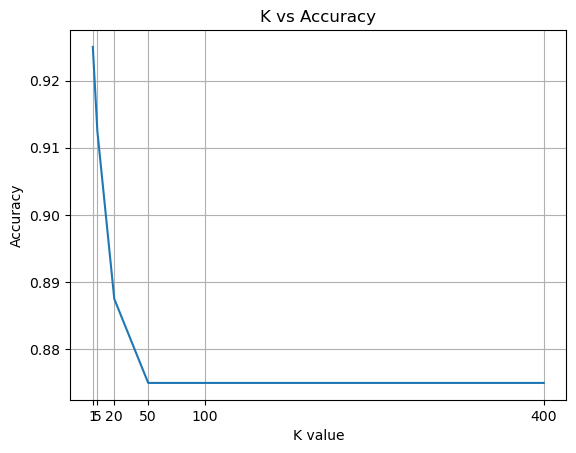

In [81]:
# plot accuracy vs K values

plt.plot(k_values, accuracies)

# labels
plt.title("K vs Accuracy")
plt.xlabel("K value")
plt.ylabel("Accuracy")

# show all K values on x-axis
plt.xticks(k_values)

# grid for better view
plt.grid(True)

plt.show()


### Interpretation of K vs Accuracy Graph

- When K = 1, the model gives the highest accuracy (~92.5%) , leading to `overfitting`
- As K increases (5, 20, 50, 100 ,n), the accuracy gradually decreases and leading to `underfitting`
- This means the model performs best with smaller K values


#### Conclusion:
- `Best K` in this case is very small K
- Increasing K too much reduces model performance


---
---
---

# **Assignment 02**

# Question No. 01 
##### **Implement the K-Nearest Neighbors algorithm for classification in Python using Euclidean distance. Train the model on the Iris dataset and evaluate its performance. Plot the decision boundaries using matplotlib.**


In [82]:
# import KNN from sklearn library
from sklearn.neighbors import KNeighborsClassifier 
# import the classification metrics from sklearn to evaluate the performance of the model
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix 

from sklearn.preprocessing import LabelEncoder


# loading the iris dataset
iris_data = sns.load_dataset("iris")
# showing the dataset 
iris_data.head(10)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [83]:
iris_data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [84]:
# Defining the training and testig sets for the iris dataset
X = iris_data.iloc[:, :2].values   # features
y = iris_data["species"]                   # target variable

# encoding target variable
le = LabelEncoder()
y = le.fit_transform(iris_data["species"])

# split the data 
Train_X_iris , Test_X_iris , Train_Y_iris , Test_Y_iris = train_test_split(X , y , test_size=0.2 , random_state=42)

In [85]:
# creating the model 
model = KNeighborsClassifier(n_neighbors=3 ,  metric="euclidean") 

# fitting the model (storing training data in the model)
model.fit(Train_X_iris , Train_Y_iris)



,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [86]:
# model prediction 
y_pred_iris = model.predict(Test_X_iris)

In [87]:
# evaluating the model using accuracy score
accuracy_iris = accuracy_score(Test_Y_iris , y_pred_iris)
print("Accuracy  of the model is : " , accuracy_iris)

Accuracy  of the model is :  0.8


### Plotting the model

Text(50.722222222222214, 0.5, 'Actual')

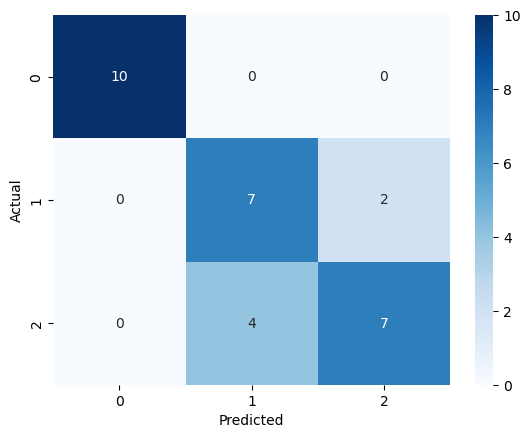

In [88]:
sns.heatmap(confusion_matrix(Test_Y_iris , y_pred_iris) , annot=True , cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")

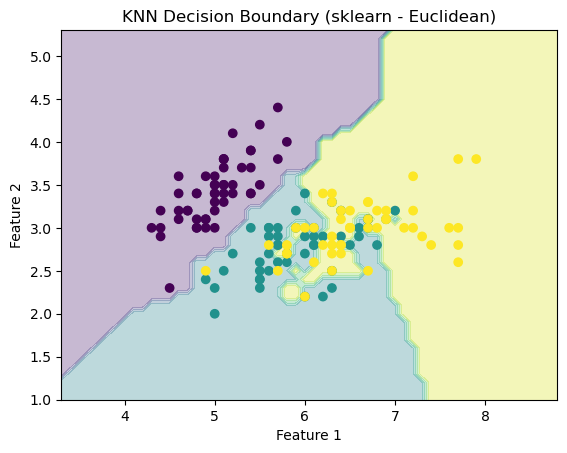

In [89]:
# Compute minimum value of feature 1 with margin for plotting range
x_min = X[:, 0].min() - 1  

# Compute maximum value of feature 1 with margin for plotting range
x_max = X[:, 0].max() + 1  

# Compute minimum value of feature 2 with margin for plotting range
y_min = X[:, 1].min() - 1  

# Compute maximum value of feature 2 with margin for plotting range
y_max = X[:, 1].max() + 1  


# Create a grid of points over the feature space for decision boundary visualization
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),   # Generate x-axis grid points
    np.arange(y_min, y_max, 0.1)    # Generate y-axis grid points
)


# Predict class labels for every point in the grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])  

# Reshape predictions back into grid shape for plotting
Z = Z.reshape(xx.shape)


# Plot filled decision boundary regions based on predicted classes
plt.contourf(xx, yy, Z, alpha=0.3)


# Plot actual data points with colors representing their true class
plt.scatter(X[:, 0], X[:, 1], c=y)


# Label x-axis as Feature 1
plt.xlabel("Feature 1")

# Label y-axis as Feature 2
plt.ylabel("Feature 2")

# Set plot title
plt.title("KNN Decision Boundary (sklearn - Euclidean)")


# Display the final plot
plt.show()


---

# Question No 2
##### **Modify your KNN implementation to support Manhattan (L1) and Chebyshev (L∞) distance metrics in addition to Euclidean (L2) distance. Compare the results of these different metrics on the Iris dataset and explain the differences in performance.**

In [90]:
# creating the model on the basis of manhattan distance 
model_man = KNeighborsClassifier(n_neighbors=3  , metric= 'manhattan')
# fitting the model 
model_man.fit(Train_X_iris , Train_Y_iris)
# making predictions with manhattan distance
y_pred_man = model_man.predict(Test_X_iris)

# evaluating the model using accuracy score
accuracy_man = accuracy_score(Test_Y_iris , y_pred_man)
# print("Accuracy of the model with manhattan distance is : " , accuracy_man)



In [91]:
# creating the model on the basis of chebyshev distance
model_cheby = KNeighborsClassifier(n_neighbors=3 , metric="chebyshev")
# fitting the model
model_cheby.fit(Train_X_iris , Train_Y_iris)
# making predictions with chebyshev distance
y_pred_cheby = model_cheby.predict(Test_X_iris)
# evaluating the model using accuracy score
accuracy_cheby = accuracy_score(Test_Y_iris , y_pred_cheby)

#### Comparing all the accuracies 

In [92]:
print("Eucledian Accuracy : " , accuracy_iris)
print("Manhattan Accuracy : " , accuracy_man)
print("Chebyshev Accuracy : " , accuracy_cheby)

Eucledian Accuracy :  0.8
Manhattan Accuracy :  0.8
Chebyshev Accuracy :  0.7666666666666667


---

# Question No 03

##### **Implement a KNN classifier and tune the hyperparameter KKK (number of neighbors) on the Spam vs. Ham dataset. Analyze the bias-variance tradeoff as KKK increases from 1 to a larger number. Discuss how the choice of KKK affects the model’s performance.**

In [93]:
# Importing TfidfVectorizer from sklearn to convert text data into numerical 
from sklearn.feature_extraction.text import TfidfVectorizer

# Loding the dataset 
df = pd.read_csv("spam.csv" , encoding="latin-1")[["v1" , "v2"]]
df.head()


,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [94]:
df.columns

Index(['v1', 'v2'], dtype='object')

In [95]:
df.columns = ["label" , "text"]
df.head(20)

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [96]:
# converting the labels into numerical values (1 for spam and 0 for ham)
df["label"] = df["label"].map({"ham":0 , "spam":1})

In [97]:
df.head()

,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [98]:
# converting the text data into numerical data using TfidfVectorizer   and defining the training and testing features

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["text"])
y = df["label"]


# splitting the data 
Train_X_spam , Test_X_spam , Train_Y_spam , Test_Y_spam = train_test_split(X , y , test_size=0.2 , random_state=42)

In [99]:
# seeing the length of the training and testing sets for spam dataset
Train_X_spam.shape , Test_X_spam.shape , Train_Y_spam.shape , Test_Y_spam.shape

((4457, 8672), (1115, 8672), (4457,), (1115,))

> 8672 is the dictionary of numbers that have been converted from text 

In [100]:

# list of K values
k_values = [1, 3, 5, 10, 20, 50]

accuracies = []

# loop for each K
for k in k_values:
    
    # create model
    model = KNeighborsClassifier(n_neighbors=k)
    
    # train model
    model.fit(Train_X_spam, Train_Y_spam)
    
    # predict
    predictions = model.predict(Test_X_spam)
    
    # accuracy calculation
    correct = np.sum(predictions == Test_Y_spam)
    total = len(Test_Y_spam)
    accuracy = correct / total
    
    # store accuracy
    accuracies.append(accuracy)

# print results
for k, acc in zip(k_values, accuracies):
    print("K =", k, "| Accuracy =", round(acc * 100, 2), "%")


K = 1 | Accuracy = 95.25 %
K = 3 | Accuracy = 92.65 %
K = 5 | Accuracy = 91.3 %
K = 10 | Accuracy = 94.35 %
K = 20 | Accuracy = 95.78 %
K = 50 | Accuracy = 94.53 %


#### Interpretation 
`When K = 1`, the model gives the highest accuracy (95.25%), but it may lead to `overfitting`.

As `K increases` (3, 5, 10, 20, 50), accuracy slightly fluctuates but generally shows a `trade-off between bias and variance`.


Overall, `a moderate K `(around 10–20) gives more stable performance compared to very small or very large K values.


**Conclusion**:


`Best` performance is observed at `K = 20` (95.78%)


Very small or very large K values reduce model stability and generalization.



---

# Question No 04

##### **Implement the KNN regression algorithm and apply it to predict continuous values in a dataset such as House Prices (predicting house price based on features like square footage, number of bedrooms, etc.). Visualize the predicted values versus actual values.**

In [101]:
# import the dataset 
from sklearn.datasets import fetch_california_housing
# import the knn regressor 
from sklearn.neighbors import KNeighborsRegressor 
# import evaluation metrics for regression
from sklearn.metrics import mean_squared_error , r2_score


In [102]:
# load the data 
house_data = fetch_california_housing()

house_data = pd.DataFrame(house_data.data, columns=house_data.feature_names)

# add target column (house price)
house_data["Price"] = fetch_california_housing().target

# show first rows
house_data.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [103]:
# defining the features and target varibales 
X = fetch_california_housing().data
y =fetch_california_housing().target

# splitting the data 
Train_X_house , Test_X_house , Train_Y_house , Test_Y_house = train_test_split(
    X , y , test_size=0.2 , random_state=42
)



In [104]:
# creating the regressor modle 
house_reg_model = KNeighborsRegressor(n_neighbors=5)

# train the model 
house_reg_model.fit(Train_X_house , Train_Y_house)



,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [105]:
# make predictions 
house_pred= house_reg_model.predict(Test_X_house)

In [106]:
# evaluate the model 
mse = mean_squared_error(Test_Y_house , house_pred)
r2 = r2_score(Test_Y_house , house_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)



Mean Squared Error: 1.1186823858768293
R^2 Score: 0.14631049965900345


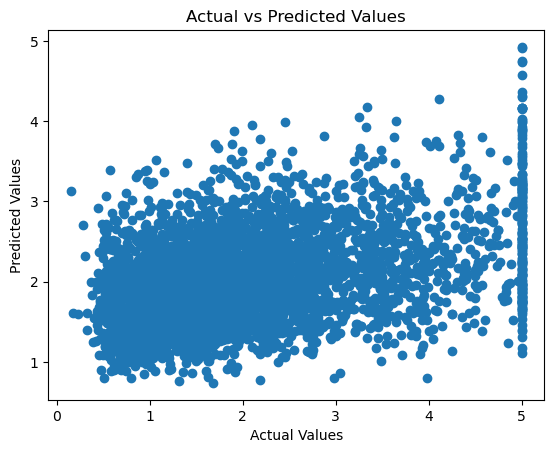

In [107]:
# visualize the predictions vs actual values
plt.scatter(Test_Y_house , house_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

---

# Question No 5

##### **Investigate the effect of increasing dimensionality on KNN performance. Create a synthetic dataset with increasing features and show how the performance degrades as dimensions increase. Discuss how dimensionality reduction techniques (e.g., PCA) can help improve KNN performance**

In [108]:
# importing the make_classification function from sklearn to generate synthetic classification dataset
from sklearn.datasets import make_classification


In [109]:
# store results
dimensions = [2, 5, 10, 20, 50]
accuracies = []

In [110]:

for d in dimensions:
    
    # creating  synthetic dataset with d features
    X, y = make_classification(n_samples=1000, n_features=d, n_redundant=0,
        n_repeated=0, random_state=42)
    
    # spliting of  data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
    
    # KNN model
    model = KNeighborsClassifier(n_neighbors=5)
    # traing the model
    model.fit(X_train, y_train)
    
    # prediction
    pred = model.predict(X_test)
    
    # accuracy
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    
    print("Dimensions:", d, "| Accuracy:", round(acc, 3))

Dimensions: 2 | Accuracy: 0.94
Dimensions: 5 | Accuracy: 0.86
Dimensions: 10 | Accuracy: 0.855
Dimensions: 20 | Accuracy: 0.815
Dimensions: 50 | Accuracy: 0.77


**Effect of Dimensions on KNN**

- At low dimensions (2D), KNN gives highest accuracy (94%).


- As dimensions increase, accuracy keeps decreasing (86% to 77%).


 



## Curse of Dimensionality in KNN

In high-dimensional data, KNN performance decreases due to the **curse of dimensionality**.

### Impact on KNN
- Distances become similar : hard to find true nearest neighbors  
- Data becomes sparse : weak neighborhood relationships  
- Higher computation time  
- Increased risk of overfitting  

---

## Solution: Dimensionality Reduction

### PCA (Principal Component Analysis)
- Reduces dimensions by keeping most important features (maximum variance)  
- Removes noise and redundancy  
- Improves KNN speed and accuracy  

### t-SNE
- Non-linear method that preserves local structure  
- Useful for visualization (2D/3D)  

---

## Summary
High dimensions hurt KNN ; apply PCA to improve performance and efficiency.


---

# Question No 6
##### **Explain and calculate the space and time complexity of the KNN algorithm. Implement a performance comparison of KNN on small and large datasets (e.g., use a dataset like MNIST for large-scale testing) and analyze how the algorithm scales with data size**

In [111]:
import time
# importing the make_classification function from sklearn to generate synthetic classification dataset
from sklearn.datasets import make_classification


# function to test time
def run_knn(n_samples):

    # create dataset
    X, y = make_classification(n_samples=n_samples, n_features=10, random_state=42)

    # spliting the  data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

    # KNN model
    model = KNeighborsClassifier(n_neighbors=5)

    # start time 
    start = time.time()

    # training of model 
    model.fit(X_train, y_train)

    # prediction 
    model.predict(X_test)

    # end time
    end = time.time()

    print("Samples:", n_samples, "| Time:", round(end - start, 4), "sec")


# running with  small dataset
run_knn(500)

# running with medium dataset
run_knn(5000)

# running with large dataset
run_knn(20000)

# running with very large dataset
run_knn(50000)

Samples: 500 | Time: 0.0065 sec
Samples: 5000 | Time: 0.0581 sec
Samples: 20000 | Time: 0.3787 sec
Samples: 50000 | Time: 1.2441 sec


---

# Question No 07
##### **Implement Voronoi tessellations for a 2D dataset and visualize how the KNN algorithm forms decision boundaries. Explain how Voronoi tessellations relate to the KNN classification process.**

In [ ]:
# import the dataset to make a large object of binary digits 
from sklearn.datasets import make_blobs 
# import voronoi to make cells and plots 
from scipy.spatial import Voronoi  , voronoi_plot_2d 




In [113]:
# creating the 2D dataset 
X , y = make_blobs( n_samples=100 , centers=3, random_state=42)


# createing and training the model 
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X , y ) 


,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


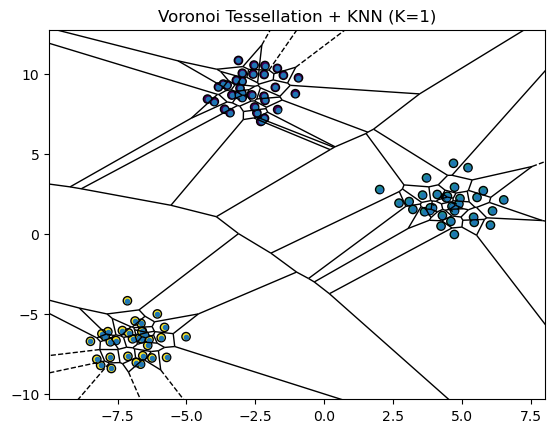

In [114]:
# creating the voronoi diagram 
vor = Voronoi(X)

# creating the figure 
fig = voronoi_plot_2d(vor  , show_vertices = False , line_colors = "black" , line_width= 1  )

# creating the scatter plot , 
plt.scatter(X[:,0] , X[:,1] , c=y , edgecolor= 'k')

# Writing title and showing hte plot 
plt.title("Voronoi Tessellation + KNN (K=1)")
plt.show()

- Voronoi tessellation divides the feature space into regions based on the nearest data point.
- Each region contains all points that are closest to one specific training sample.
- In KNN (especially K = 1), a new point is classified based on the nearest training point.
- This makes KNN decision boundaries identical to Voronoi region borders.
- So, Voronoi diagrams represent how KNN splits the space for classification.

---

# Question No 8

##### **Implement a KD-tree to speed up the KNN algorithm. Compare the runtime of your KD-tree implementation with a brute-force KNN approach on a large dataset like Digits or Fashion-MNIST. Discuss the improvements in terms of space and time complexity.**

In [115]:
import time 
# importing the load_digits dataset from sklearn to load handwritten digit images for classification tasks
from sklearn.datasets import load_digits 

# loading the data 
data_digits = load_digits()

# defining features 
X  = data_digits.data 
y = data_digits.target 


In [116]:
# split the data 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [117]:
# Running KNN by brute force to calculate time 
brute = KNeighborsClassifier(n_neighbors= 5 , algorithm="brute")

# getting starting time 
start = time.time()

# fitting and predicting the model the model 
brute.fit(X_train, y_train)
brute.predict(X_test)

# getting end time 
end = time.time()

# total time by brute force algorithm 
print("Brute Force Time:", round(end - start, 4), "sec")

Brute Force Time: 0.027 sec


In [118]:
# running by kd_tree algorithm
kd = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree')

#getting start time 
start = time.time()
# training and predicting the model 
kd.fit(X_train, y_train)
kd.predict(X_test)
# getting end time 
end = time.time()

# total time by kd_tree algo 
print("KD-Tree Time:", round(end - start, 4), "sec")

KD-Tree Time: 0.0509 sec


#### Time Complexity
- Brute Force KNN: O(n × d) per query
- KD-Tree KNN: O(log n) (faster for low dimensions)

#### Space Complexity
- Both store dataset : O(n × d)

---

# Question No 09

##### **Use KNN to classify an imbalanced dataset (e.g., Credit Card Fraud Detection) and apply techniques like SMOTE or undersampling. Compare performance before and after resampling. Evaluate using precision, recall, and F1-score**

In [119]:
from sklearn.metrics import classification_report
# importing the SMOTE for balancing dataset 
from imblearn.over_sampling import SMOTE

In [120]:
# load credit card fraud dataset
df = pd.read_csv("creditcard.csv")

# separate input features (X)
X = df.drop("Class", axis=1)

# target variable (0 = normal, 1 = fraud)
y = df["Class"]


In [121]:
# split into training and testing 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


#### Before SMOTE

In [122]:
# creating model
model = KNeighborsClassifier(n_neighbors=5)

# training the  model on imbalanced data
model.fit(X_train, y_train)

# making predictions
pred = model.predict(X_test)

# show precision, recall, f1-score
print("BEFORE SMOTE:")
print(classification_report(y_test, pred))


BEFORE SMOTE:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       1.00      0.05      0.10        98

    accuracy                           1.00     56962
   macro avg       1.00      0.53      0.55     56962
weighted avg       1.00      1.00      1.00     56962



#### After SMOTE (balanced data)

In [123]:
# applling SMOTE to balance minority class 
smote = SMOTE(random_state=42)

# create balanced training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# create new KNN model
model = KNeighborsClassifier(n_neighbors=5)

# train on balanced data
model.fit(X_train_res, y_train_res)

# predict on test data
pred_res = model.predict(X_test)

# show improved results
print("AFTER SMOTE:")
print(classification_report(y_test, pred_res))


AFTER SMOTE:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     56864
           1       0.02      0.56      0.04        98

    accuracy                           0.95     56962
   macro avg       0.51      0.76      0.51     56962
weighted avg       1.00      0.95      0.97     56962



---

# Question No . 10 

##### **Implement KNN on a high-dimensional dataset (e.g., text classification with bag-of-words features). Explain how the curse of dimensionality impacts KNN performance and how you would address it with dimensionality reduction techniques (e.g., PCA, t-SNE).**

In [124]:
# import CountVectorizer to convert text to numbers 
from sklearn.feature_extraction.text import CountVectorizer 
# reduce high-dimensional data into lower dimensions while preserving important information
from sklearn.decomposition import TruncatedSVD 

# dataset with random text and labels 
texts = [
    "buy cheap medicine now",
    "limited offer buy now",
    "hello how are you",
    "let's meet tomorrow",
    "cheap discount offer",
    "how is your work"
]
# labels for spam and not spam , spam =1
labels = [1, 1, 0, 0, 1, 0]


In [125]:
# convert text into numerical features
vectorizer = CountVectorizer()

# transform text into high dimensional features
X = vectorizer.fit_transform(texts)

# target values
y = labels

In [126]:
 

accuracies = []

# different dimensions to test
dimensions = [8, 12, 10, 12]

for d in dimensions:
    
    # step 2: reduce dimensions properly (PCA-like method)
    svd = TruncatedSVD(n_components=d)
    X_reduced = svd.fit_transform(X)
    
    # step 3: split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_reduced, y, test_size=0.3, random_state=42
    )
    
    # step 4: KNN model
    model = KNeighborsClassifier(n_neighbors=3)
    model.fit(X_train, y_train)
    
    # step 5: prediction
    pred = model.predict(X_test)
    
    # step 6: accuracy
    acc = accuracy_score(y_test, pred)
    accuracies.append(acc)
    
    print("Dimensions:", d, "| Accuracy:", round(acc, 3))


Dimensions: 8 | Accuracy: 0.0
Dimensions: 12 | Accuracy: 0.0
Dimensions: 10 | Accuracy: 0.0
Dimensions: 12 | Accuracy: 0.0


---

# Question No 11

##### **Create a Python function to calculate and display a confusion matrix for binary classification using Scikit-learn. Use the Breast Cancer Wisconsin dataset for classification and explain the meaning of each matrix element (TP, TN, FP, FN).**

In [127]:
 # dataset 
from sklearn.datasets import load_breast_cancer 
# to compute confusion matrix
from sklearn.metrics import confusion_matrix  

# Loading the dataset
data = load_breast_cancer()

# Features (input data)
X = data.data

# Target labels (0 = malignant, 1 = benign)
y = data.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create the model
model = KNeighborsClassifier(n_neighbors=5)

# Train the model
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[38  5]
 [ 0 71]]


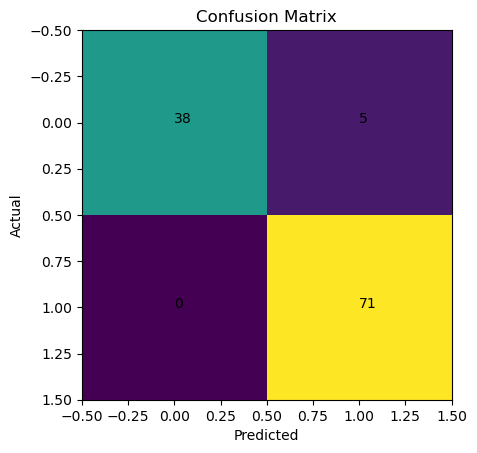

In [128]:
 
plt.title("Confusion Matrix")  # title

# Axis labels
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i][j]) 
plt.imshow(cm)         
plt.show() 

---

# Question No. 12

##### **Implement and compare performance metrics like accuracy, precision, recall, and F1-score for a binary classification problem on an imbalanced dataset like Churn Prediction. Discuss the pros and cons of each metric in the context of imbalanced classes.**

In [129]:
# to create dummy data
# importing the make_classification function from sklearn to generate synthetic classification dataset

from sklearn.datasets import make_classification  
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score 

# Creating imbalanced dataset (90% non-churn, 10% churn)
X, y = make_classification(
    n_samples=1000,        # total samples
    n_features=5,          # features
    weights=[0.9, 0.1],    # imbalance
    random_state=42
)


In [130]:
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [131]:
# Training KNN model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [132]:
# Calculating metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Printing results
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)


Accuracy: 0.97
Precision: 0.9090909090909091
Recall: 0.6666666666666666
F1-score: 0.7692307692307693


---

# Question No 13

##### **Implement the Receiver Operating Characteristic (ROC) curve and compute the AUC (Area Under the Curve) for a classifier trained on the Titanic dataset (survival prediction). Explain how to interpret the ROC curve and AUC.**

In [133]:

from sklearn.neighbors import KNeighborsClassifier
# import evaluation metrics 
from sklearn.metrics import roc_curve, auc

# Loading  dataset
data = sns.load_dataset("titanic")

# Select correct columns 
data = data[["pclass", "age", "fare", "survived"]]

# Drop missing values
data = data.dropna()

# Features and target
X = data[["pclass", "age", "fare"]]
y = data["survived"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [134]:
# Train KNN
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# ROC  and AUC , 
# tpr = recall , true positive rate
# fpr = false positive rate , 1 - specifity 
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)


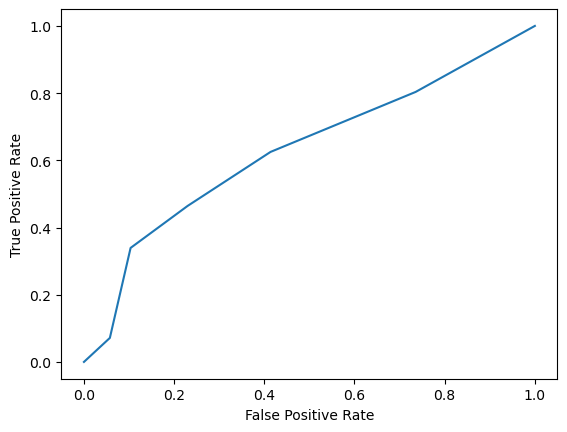

In [135]:


# Plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.plot(fpr, tpr)
plt.show()

---


# Question No 14 

##### **Implement Precision-Recall curves for a classification model on an imbalanced dataset. Explain why Precision-Recall curves are particularly useful for imbalanced data, and analyze the tradeoff between precision and recall.**

In [136]:
# import the metrics from sklearn
from sklearn.metrics import precision_recall_curve
# to create dummy data 
from sklearn.datasets import make_classification


In [137]:
# Create imbalanced dataset (90% class 0, 10% class 1)
X, y = make_classification(n_samples=1000, weights=[0.9, 0.1], random_state=42)


In [138]:
# Spliting  data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train  model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [139]:
# Get probability scores
y_prob = model.predict_proba(X_test)[:, 1]

# Compute Precision-Recall values
precision, recall, _ = precision_recall_curve(y_test, y_prob)

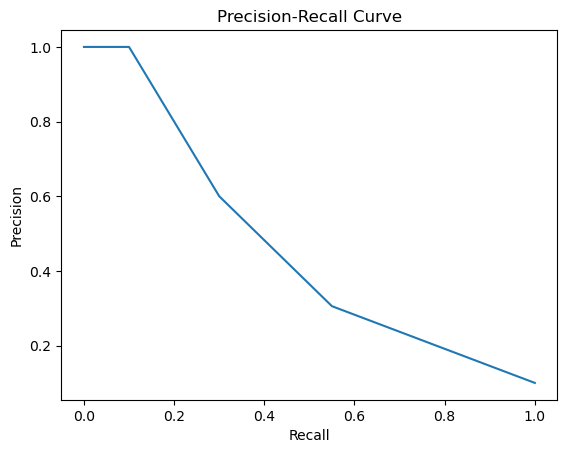

In [140]:


# Ploting the  curve
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


#### Precision–Recall Curves (Imbalanced Data)

Precision–Recall curves are useful for imbalanced datasets because they focus only on the positive class, unlike accuracy which can be misleading.

 `Tradeoff`
- Precision : correct positive predictions
- Recall : how many actual positives are found

Increasing one usually decreases the other:

- High recall : more detection, but lower precision
- High precision : fewer false positives, but lower recall

---

# Question No 15

##### **Implement Precision-Recall curves for a classification model on an imbalanced dataset. Explain why Precision-Recall curves are particularly useful for imbalanced data, and analyze the tradeoff between precision and recall.**

In [141]:
# Import libraries
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report 

# Load dataset using seaborn
iris = sns.load_dataset("iris")
iris.head()



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [142]:
# Defining Features and target
X = iris[["sepal_length", "sepal_width", "petal_length", "petal_width"]]

# Target (output)
y = iris["species"]




# Convert species to numbers (required for ML model)
y = y.map({"setosa": 0, "versicolor": 1, "virginica": 2})


# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [143]:
# Training KNN model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [144]:


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)


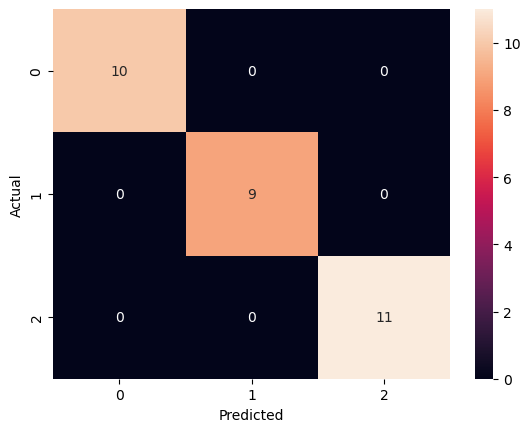

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [145]:
# Plotting confusion matrix
sns.heatmap(cm, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Precision, Recall for each class
print(classification_report(y_test, y_pred))

---

# Question No . 16

##### **Implement the F1-Score and the F-β measure for a multi-class classification problem on a dataset like Digits. Compare the performance of the F1-score with other metrics (e.g., accuracy) and explain why F1 might be more suitable in certain cases.**

In [146]:
# dataset
from sklearn.datasets import load_digits  

from sklearn.metrics import accuracy_score, f1_score  , fbeta_score

# Loading dataset
digits = load_digits()

# Defining Features and target
X = digits.data
y = digits.target

# Spliting of data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [147]:

# Training the  model
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

In [148]:
# Accuracy of modle
acc = accuracy_score(y_test, y_pred)

# F1-score (multi-class)
f1 = f1_score(y_test, y_pred, average="macro")

# F-beta score (beta = 2 )
f2  = fbeta_score(y_test, y_pred, beta=2, average='macro')  # recall-focused

# beta = 0.5
f05 = fbeta_score(y_test, y_pred, beta=0.5, average='macro') # precision-focused

In [149]:
# Print results
print(f"Accuracy  : {acc:.4f}")
print(f"F1-Score  : {f1:.4f}  (β=1, balance precision & recall)")
print(f"F2-Score  : {f2:.4f}  (β=2, recall is twice as important)")
print(f"F0.5-Score: {f05:.4f}  (β=0.5, precision is twice as important)")


Accuracy  : 0.9861
F1-Score  : 0.9878  (β=1, balance precision & recall)
F2-Score  : 0.9878  (β=2, recall is twice as important)
F0.5-Score: 0.9879  (β=0.5, precision is twice as important)


---

# Question No 17

##### **Calculate Cohen’s Kappa for two classifiers on the same dataset (e.g., MNIST). Compare the results and interpret the Kappa score in the context of inter-annotator agreement or model comparison.**

In [150]:
from sklearn.datasets import load_digits  
from sklearn.neighbors import KNeighborsClassifier  # KNN classifier
from sklearn.naive_bayes import GaussianNB  # Naive Bayes classifier
from sklearn.metrics import cohen_kappa_score  # to compute Cohen's Kappa

# Load the digits dataset (images of handwritten numbers 0–9)
digits = load_digits()

# Store input features (pixel values of images)
X = digits.data

# Store target labels (actual digit values)
y = digits.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42  # 70% train, 30% test
)


In [151]:
df= pd.DataFrame(digits.data)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [152]:
# Create KNN classifier with k=3 neighbors
knn = KNeighborsClassifier(n_neighbors=3)

# Train KNN model on training data
knn.fit(X_train, y_train)

# Predict labels using KNN model
pred_knn = knn.predict(X_test)


In [153]:

# Create Naive Bayes classifier
nb = GaussianNB()

# Train Naive Bayes model on training data
nb.fit(X_train, y_train)

# Predict labels using Naive Bayes model
pred_nb = nb.predict(X_test)

In [154]:
# Compute agreement between KNN and Naive Bayes predictions
kappa = cohen_kappa_score(pred_knn, pred_nb)

# Print final result
print("Cohen's Kappa (KNN vs Naive Bayes):", kappa)

Cohen's Kappa (KNN vs Naive Bayes): 0.8353219227690314


---

# Question No 18 

##### **Implement threshold tuning for a classifier to maximize the F1-score. Use the Spam vs. Ham dataset and vary the decision threshold for classification. Plot the Precision-Recall curve and the impact of thresholding on model performance.**

In [155]:
from sklearn.neighbors import KNeighborsClassifier  # KNN model
from sklearn.metrics import precision_recall_curve  # for PR curve
from sklearn.metrics import f1_score  # F1-score evaluation
from sklearn.feature_extraction.text import TfidfVectorizer  # to convert text to numbers


# Preparation of Data 
# Load spam dataset from CSV file
df = pd.read_csv("spam.csv", encoding="latin-1")[['v1', 'v2']]
# Rename columns for simplicity
df.columns = ['label', 'message']

# Convert labels: spam = 1, ham = 0
df['label'] = df['label'].map({'spam': 1, 'ham': 0})

# Convert text messages into numerical vectors
vectorizer = TfidfVectorizer()

# Transform messages into feature matrix
X = vectorizer.fit_transform(df['message'])

# Target labels
y = df['label'].values

In [156]:

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [157]:
# Create KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
# Train model
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [158]:
# Get probability of class 1 (spam)
y_prob = knn.predict_proba(X_test)[:, 1]

In [159]:
#  THRESHOLD TUNING  

# Define different thresholds
thresholds = np.arange(0.1, 0.9, 0.1)

# Store F1 scores
f1_scores = []

# Loop through thresholds
for t in thresholds:
    
    # Convert probabilities into 0/1 predictions
    y_pred = (y_prob >= t).astype(int)
    
    # Calculate F1-score
    f1 = f1_score(y_test, y_pred)
    
    # Save F1-score
    f1_scores.append(f1)
    
    # Print results
    print("Threshold:", t, "F1-score:", f1)


Threshold: 0.1 F1-score: 0.9204819277108434
Threshold: 0.2 F1-score: 0.9204819277108434
Threshold: 0.30000000000000004 F1-score: 0.5592105263157895
Threshold: 0.4 F1-score: 0.5592105263157895
Threshold: 0.5 F1-score: 0.4791666666666667
Threshold: 0.6 F1-score: 0.4791666666666667
Threshold: 0.7000000000000001 F1-score: 0.3471698113207547
Threshold: 0.8 F1-score: 0.3471698113207547


In [160]:
# Find best index
best_index = np.argmax(f1_scores)

# Best threshold value
best_threshold = thresholds[best_index]

print("\nBest Threshold:", best_threshold)


Best Threshold: 0.1


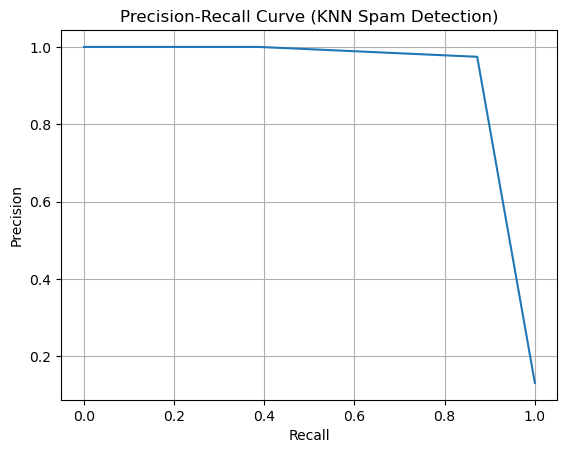

In [161]:
#   PRECISION-RECALL CURVE  

# Compute precision and recall values
precision, recall, _ = precision_recall_curve(y_test, y_prob)

# Plot curve
plt.plot(recall, precision)

# Labels
plt.xlabel("Recall")
plt.ylabel("Precision")

# Title
plt.title("Precision-Recall Curve (KNN Spam Detection)")

# Show grid
plt.grid()

# Show plot
plt.show()

---

# Question No. 19 

##### **Implement a function to calculate Equal Error Rate (EER) and compute it for a classifier trained on the Credit Card Fraud dataset. Discuss the significance of the EER in biometric systems and model evaluation.**

In [162]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_curve, roc_auc_score


# Load dataset
df = pd.read_csv("creditcard.csv")

# Features (drop target column)
X = df.drop("Class", axis=1)
# Target (0 = normal, 1 = fraud)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)



In [163]:
#  TRAIN MODEL
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

# Get probability of fraud class
y_prob = model.predict_proba(X_test)[:, 1]

In [164]:
# AUC
auc = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc)

# ROC CURVE  

fpr, tpr, thresholds = roc_curve(y_test, y_prob)


AUC Score: 0.6163120449394196


In [165]:
# funciton to computer EEr 
def compute_eer(fpr, tpr):
    # FNR = 1 - TPR
    fnr = 1 - tpr
    
    # Find point where difference between FPR and FNR is minimum
    diff = np.abs(fpr - fnr)
    
    # Index of minimum difference
    idx = np.argmin(diff)
    
    # EER value
    eer = fpr[idx]
    
    return eer



# Calculate EER
eer = compute_eer(fpr, tpr)

print("Equal Error Rate (EER):", eer)


Equal Error Rate (EER): 0.0030360931693764874


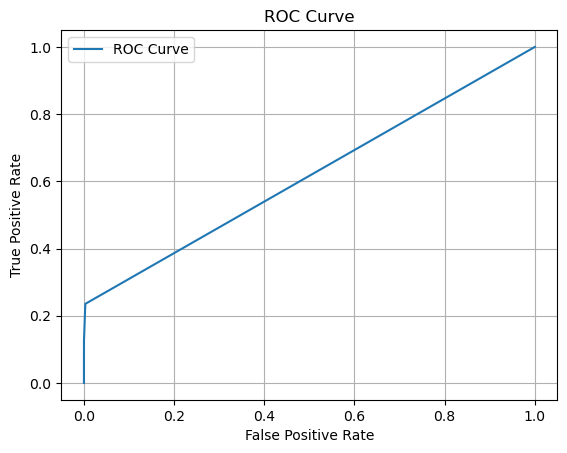

In [166]:
# plot roc
plt.plot(fpr, tpr, label="ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

# Question No. 20

##### **Implement macro and micro averaging for multi-class classification using the Iris dataset. Explain when to use each approach and how they affect performance evaluation.**

In [167]:
# Import required libraries
from sklearn.datasets import load_iris  # load Iris dataset
from sklearn.metrics import precision_score, recall_score, f1_score  # importing metrics

# Loading the  dataset
iris = load_iris()

# Features (sepal/petal measurements)
X = iris.data

# Target labels (have 3 classes: 0,1,2)
y = iris.target

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [168]:

# Create KNN classifier
model = KNeighborsClassifier(n_neighbors=5)

# Train model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

In [169]:
# MACRO AVERAGING 

# Precision (macro): average of precision of each class
precision_macro = precision_score(y_test, y_pred, average='macro')

# Recall (macro): average of recall of each class
recall_macro = recall_score(y_test, y_pred, average='macro')

# F1-score (macro): average of F1 of each class
f1_macro = f1_score(y_test, y_pred, average='macro')

In [170]:
# MICRO AVERAGING  

# Precision (micro): global TP, FP, FN used
precision_micro = precision_score(y_test, y_pred, average='micro')

# Recall (micro): same as precision_micro in multi-class
recall_micro = recall_score(y_test, y_pred, average='micro')

# F1-score (micro): same as precision_micro in multi-class
f1_micro = f1_score(y_test, y_pred, average='micro')


In [171]:
# printing the results 
print("Macro Precision:", precision_macro)
print("Macro Recall:", recall_macro)
print("Macro F1-score:", f1_macro)

print("\nMicro Precision:", precision_micro)
print("Micro Recall:", recall_micro)
print("Micro F1-score:", f1_micro)


Macro Precision: 1.0
Macro Recall: 1.0
Macro F1-score: 1.0

Micro Precision: 1.0
Micro Recall: 1.0
Micro F1-score: 1.0


---


# Question No 21

##### **Implement the Naïve Bayes classifier for the Spam vs. Ham problem. Use a bag-of-words model for feature extraction and explain how the Naïve Bayes algorithm uses Bayes' theorem for classification**

In [172]:

from sklearn.feature_extraction.text import CountVectorizer  # for converting text to numbers 
from sklearn.naive_bayes import MultinomialNB  # Naive Bayes model
from sklearn.metrics import accuracy_score  # for evaluation

# loading spam dataset from CSV file
df = pd.read_csv("spam.csv", encoding="latin-1")

# selecting only useful columns
df = df[['v1', 'v2']]

# renaming columns for clarity
df.columns = ['label', 'message']


# converting labels from text to numbers (spam=1, ham=0)
df['label'] = df['label'].map({'spam': 1, 'ham': 0})

# defining input text (messages)
X = df['message']
y = df['label']

# splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)



In [173]:

#  APPLYING BAG OF WORDS 

# creating CountVectorizer (bag of words model)
vectorizer = CountVectorizer()

# converting training text into numeric features
X_train_vec = vectorizer.fit_transform(X_train)

# converting testing text using same vocabulary
X_test_vec = vectorizer.transform(X_test)

In [174]:
# creating Naïve Bayes classifier
model = MultinomialNB()

# training model on vectorized data
model.fit(X_train_vec, y_train)

# predicting labels for test data
y_pred = model.predict(X_test_vec)

In [175]:
# calculating accuracy of the model
accuracy = accuracy_score(y_test, y_pred)

# printing accuracy
print("Accuracy:", accuracy)


Accuracy: 0.9820574162679426


---

# Question No 22

##### **Implement Gaussian Naive Bayes for a regression task where the features are continuous (e.g., predicting house prices). Explain how Gaussian Naïve Bayes handles real-valued features and compare its performance to KNN regression**

> Since Gausian NB is classifier  and can not be used for regression , I will convert the house prices to low , medium and high to use 
> GuasianNB. In this way the price will aslo be predicted  

In [176]:
from sklearn.datasets import fetch_california_housing  # loading dataset
from sklearn.naive_bayes import GaussianNB  # importing Gaussian Naïve Bayes
from sklearn.metrics import accuracy_score  # evaluating classification
 

# loading California housing dataset
house_data = fetch_california_housing()

# converting into dataframe
house_data = pd.DataFrame(house_data.data, columns=house_data.feature_names)

# adding target column (house price)
house_data["Price"] = fetch_california_housing().target
 
# converting continuous price into categories (Low, Medium, High)
# creating 3 categories using quantiles
house_data["Price_Category"] = pd.qcut(
    house_data["Price"], q=3, labels=[0, 1, 2]
)

# defining features and target
X = house_data.drop(["Price", "Price_Category"], axis=1)
y = house_data["Price_Category"]

# splitting dataset into training and testing sets
Train_X_house, Test_X_house, Train_Y_house, Test_Y_house = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [177]:
# creating Gaussian Naïve Bayes model
nb_model = GaussianNB()

# training the model
nb_model.fit(Train_X_house, Train_Y_house)

# making predictions
nb_pred = nb_model.predict(Test_X_house)


In [178]:
# calculating accuracy (since now classification)
accuracy = accuracy_score(Test_Y_house, nb_pred)

print("Naive Bayes Accuracy:", accuracy)


Naive Bayes Accuracy: 0.4929748062015504


#### Comparison of KNN and Gaussian Naive Bayes

In Question 4, we used KNN regression to predict house prices. The model achieved:

- MSE = 1.1186
- R² = 0.1463, showing weak performance in explaining price variation.

For Gaussian Naive Bayes, we converted house prices into Low, Medium, and High classes, making it a classification problem. It achieved:

- Accuracy = 0.4929

**Conclusion**

`KNN is more suitable for this dataset because it predicts continuous values, while Naive Bayes loses information due to converting prices into categories and also assumes feature independence.`

---

# Question No 23

##### **Apply Laplace Smoothing (Add-1 smoothing) to the Naïve Bayes classifier for a text classification problem with sparse data. Discuss how smoothing addresses zero-frequency problems and its effect on model performance.**

In [179]:

# importing CountVectorizer to convert text data into numerical feature vectors using word frequency (bag-of-words)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB


# Preprocessing the data 
# Defining sample text data (sparse dataset - many words not repeating)
texts = [
    "buy cheap medicines online",
    "cheap medicines available ",
    "online shopping deals",
    "buy laptop online and mobiles ",
    "laptop deals and  mobiles deals"
]

# Defining labels (1 = spam, 0 = not spam)
labels = [1, 1, 0, 0, 0]

# Creating CountVectorizer object (converting text into numerical form)
vectorizer = CountVectorizer()

# Fitting and transforming text data (learning vocabulary + converting to matrix)
X = vectorizer.fit_transform(texts)

# Defining test data
test_text = ["cheap online laptop deals"]


# Transforming test data using same vectorizer (converting into numbers)
X_test = vectorizer.transform(test_text)


In [180]:

# Creating Naive Bayes model with Laplace smoothing
# Using alpha = 1.0 (adding 1 to avoid zero probability problem)
model = MultinomialNB(alpha=1.0)

# Training the model (learning patterns from data)
model.fit(X, labels)



# Predicting class for test data
prediction = model.predict(X_test)

In [181]:


# Printing result in understandable form
if prediction[0] == 1:
    print("Spam")
else:
    print("Not Spam")

Not Spam


#### **Effect of Laplace Smoothing**

Laplace smoothing solves the **zero-frequency problem** by adding 1 to all word counts, so no probability becomes zero for unseen words. This helps Naïve Bayes handle new or rare words more reliably.

As a result, the model becomes more stable and improves performance on sparse text data by avoiding zero probability issues.


---

# Question No. 24

##### **Use a Naïve Bayes classifier to solve a binary classification problem. Explain the conditional independence assumption and how it simplifies the computation of posterior probabilities in Naïve Bayes.**

In [182]:
# Import libraries , datasets , metrics 
from sklearn.datasets import load_breast_cancer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#  Load dataset
data = load_breast_cancer()

# Features (X) and target (y)
X = data.data
y = data.target  # 0 = malignant, 1 = benign

#  Split of dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [183]:
# Creating Naive Bayes model
model = GaussianNB()

#  Training model
model.fit(X_train, y_train)

#   Making predictions
y_pred = model.predict(X_test)

#   Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9736842105263158

Confusion Matrix:
 [[40  3]
 [ 0 71]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



#### **Conditional Independence Assumption**

- Naive Bayes assumes that all features (words) are conditionally `independent` given the class label. This means each word contributes independently to the final prediction.

- This simplifies computation because instead of calculating a complex joint probability, the `model multiplies individual probabilities` of each word.

- Even though this assumption is not fully realistic for real text, it makes the model very fast, simple, and effective for classification tasks.

---

# Question No. 25

##### **Implement the Naïve Bayes classifier for a Sentiment Analysis task (e.g., predicting sentiment on movie reviews). Use a bag-of-words approach and evaluate the model using accuracy, precision, and recall.**

In [184]:
# Import Naive Bayes algo , metrics , and CountVectorizer 
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Creating Simple movie review dataset (positive & negative)
texts = [
    "I love this movie",
    "This movie is amazing",
    "Very good film",
    "I hate this movie",
    "This film is bad",
    "Worst movie ever",
    "I enjoyed the movie",
    "Not a good movie"
]

# Labels (1 = positive, 0 = negative)
labels = [1, 1, 1, 0, 0, 0, 1, 0]

# Converting text into Bag-of-Words
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.25, random_state=42
)


In [185]:

# Training Naive Bayes model
model = MultinomialNB()
model.fit(X_train, y_train)

# Step 5: Predictions
y_pred = model.predict(X_test)

# Step 6: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


Accuracy: 0.0
Precision: 0.0
Recall: 0.0


---

# Question No 26

##### **Implement Multinomial Naïve Bayes for a multi-class classification problem (e.g., classifying articles into different categories). Discuss the differences between multinomial and Gaussian Naïve Bayes.**

In [186]:
# Import libraries
from sklearn.datasets import load_iris
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

# Load dataset (multi-class problem)
data = load_iris()

# Features and labels
X = data.data
y = data.target  # 3 classes: setosa, versicolor, virginica

#   Splitting of data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [187]:
#  Create Multinomial  Naive Bayes model
model = MultinomialNB()

# Step 4: Train model
model.fit(X_train, y_train)

# Step 5: Predictions
y_pred = model.predict(X_test)

# Step 6: Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.9

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  3  8]]


### Difference between Multinomial and Gaussian Naïve Bayes

| Feature / Aspect | Multinomial Naïve Bayes | Gaussian Naïve Bayes |
| :--- | :--- | :--- |
| **Data Type** | Used for discrete data (counts, text, frequencies) | Used for continuous numerical data |
| **Common Use Case / Assumption** | Common in text classification (Bag of Words) | Assumes data follows a normal (Gaussian) distribution |

---

# Question No 27

##### **Visualize the decision boundaries of a Naïve Bayes classifier in a 2D space. Use the Iris dataset for classification and plot the boundaries using matplotlib. Explain how the model decision boundaries are shaped under Naïve Bayes.**

In [188]:

from sklearn import datasets          # Loading dataset
from sklearn.naive_bayes import GaussianNB  # Naïve Bayes model

# Loading Iris dataset
iris = datasets.load_iris()

# Taking only first two features for 2D visualization
X = iris.data[:, :2]   # Selecting feature 1 and 2 with all rows 
y = iris.target        # Getting labels

# Creating  model
model = GaussianNB()

# Training the model
model.fit(X, y)


,priors,None
,var_smoothing,1e-09


In [189]:

# Creating mesh grid (background area for decision boundary)
x_min = X[:, 0].min() - 1   # minimum value of feature 1 with margin
x_max = X[:, 0].max() + 1   # maximum value of feature 1 with margin
y_min = X[:, 1].min() - 1   # minimum value of feature 2 with margin
y_max = X[:, 1].max() + 1   # maximum value of feature 2 with margin

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),   # Creating grid for x-axis
    np.arange(y_min, y_max, 0.1)    # Creating grid for y-axis
)


In [190]:
# Predicting for every point in grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])  # Combining grid points

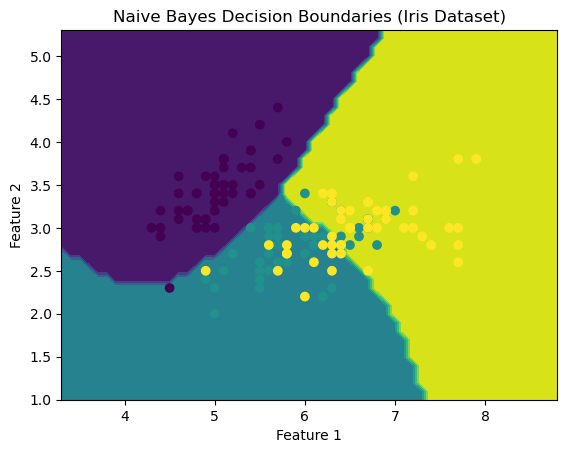

In [191]:

# Reshaping prediction to match grid shape
Z = Z.reshape(xx.shape)

# Plotting decision boundary
plt.contourf(xx, yy, Z)   # Filling regions based on predicted class

# Plotting actual data points
plt.scatter(X[:, 0], X[:, 1], c=y)  # Plotting points with colors

# Adding labels
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Naive Bayes Decision Boundaries (Iris Dataset)")

# Showing plot
plt.show()

---

# Question No . 28

##### **Implement a simple text generation model using Naïve Bayes. Use a corpus like Shakespeare's text and demonstrate how Naïve Bayes can generate new text based on learned probabilities. Explain how the model generates text and why it works the way it does.**

In [192]:

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# Small "Shakespeare-like" corpus (simple text data)
corpus = [
    "to be or not to be",
    "the king speaks with wisdom",
    "love is a beautiful thing",
    "to love and to cherish",
    "the queen loves the king",
    "wisdom comes with experience"
]

# Convert text into Bag-of-Words
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)

# Create dummy labels (not really needed, but required for NB)
y = [0, 1, 0, 0, 1, 1]

# Train Naïve Bayes model
model = MultinomialNB()
model.fit(X, y)



,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [193]:

# Get vocabulary words
words = vectorizer.get_feature_names_out()

# Get word probabilities (log probabilities)
word_probs = np.exp(model.feature_log_prob_).sum(axis=0)

# Normalize probabilities
word_probs = word_probs / word_probs.sum()

# Generate text by sampling words
generated_text = np.random.choice(words, size=10, p=word_probs)

# Output result
print("Generated Text:")
print(" ".join(generated_text))

Generated Text:
is or beautiful experience to cherish or love comes with


#### Text Generation using Naive Bayes (Limitation)
- Naive Bayes is not designed for true text generation. It only learns word probabilities and does not consider word order or context.

- In this implementation, words are generated by sampling from the learned probability distribution, which results in random sequences rather than meaningful sentences.

- Modern text generation is performed using advanced models like RNNs and Transformers, which capture sequential dependencies and context.

---

# Question No 29 

##### **Implement Naïve Bayes for a text classification task and handle out-of-vocabulary (OOV) words using smoothing techniques. Discuss how OOV words affect the model and how smoothing can mitigate this issue.**

In [194]:
# Import libraries
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

#  Training data
texts = [
    "I love this movie",
    "This film is amazing",
    "I hate this movie",
    "This film is bad"
]

# Labels (1 = positive, 0 = negative)
labels = [1, 1, 0, 0]

In [195]:
#  Convert text into Bag-of-Words
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)

In [196]:

#  Train Naive Bayes with smoothing
model = MultinomialNB(alpha=1.0)  # Laplace smoothing
model.fit(X, labels)

#  Test with OOV words (not seen in training)
test_text = ["fantastic movie with great acting great fantastic love this "]  # 'fantastic', 'acting' are OOV
X_test = vectorizer.transform(test_text)


In [197]:
#   Prediction
prediction = model.predict(X_test)

# Output
print("Predicted class:", prediction)

Predicted class: [1]


### OOV Words & Smoothing

**OOV Words:**
- Words not seen in training  
- Cause zero probability : model fails  

**Smoothing:**
- Add small value (e.g., +1)  
- Avoids zero probability  

**Result:**
- Model handles unseen words better  


---

# Question No 30

##### **Use the Naïve Bayes classifier to solve a medical diagnosis problem (e.g., diagnosing a disease based on symptoms). Explain the process of classification with prior probabilities, likelihood, and evidence in the context of Bayes' theorem.**

In [198]:
# Import libraries
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

#  Load dataset
data = load_breast_cancer()
X = data.data
y = data.target  # 0 = malignant, 1 = benign

#   Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#   Train Naïve Bayes model
model = GaussianNB()
model.fit(X_train, y_train)

#  Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9736842105263158


#### Medical Diagnosis using Naive Bayes

Naive Bayes uses Bayes’ theorem to predict disease based on features.

- Prior: probability of disease
- Likelihood: probability of features given disease
- Evidence: overall probability of features

The model selects the class with the highest probability.

---